# Adult Income Dataset — EDA
**Owner: Salman Ali Khan**

Complete this notebook before implementing `src/preprocessing/adult.py`.
**Important notes:**
- Missing values are encoded as `?` (not NaN)
- `fnlwgt` is a census sampling weight — drop it, it is not predictive
- Target `income` has two values: `<=50K` and `>50K` — binarise to 0/1
- The dataset is imbalanced: ~76% earn <=50K

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv('../data/adult/adult.data', header=None, names=COLUMNS,
                 sep=',', skipinitialspace=True)
df.drop(columns=['fnlwgt'], inplace=True)
print('Shape:', df.shape)
df.head()

Shape: (32561, 14)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
import os

SAVE_DIR = os.path.abspath("../visualizations/eda/adult")
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Plots will be saved to: {SAVE_DIR}")

Plots will be saved to: c:\Users\ibrah\Documents\University\Semester6\ML\Project\XAI\visualizations\eda\adult


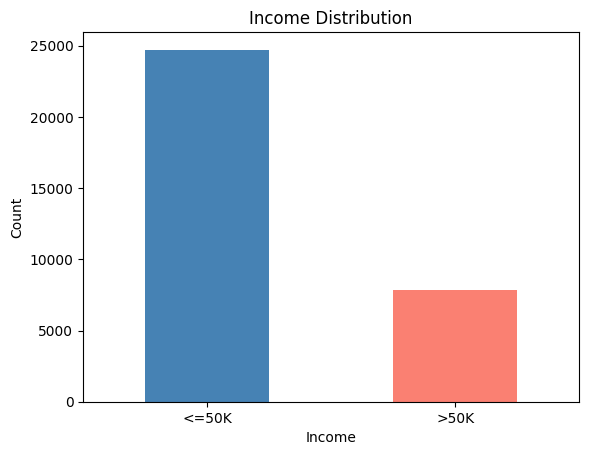

income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


In [3]:
# Target distribution
df['income'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig(os.path.join(SAVE_DIR, 'income_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(df['income'].value_counts(normalize=True).round(3))

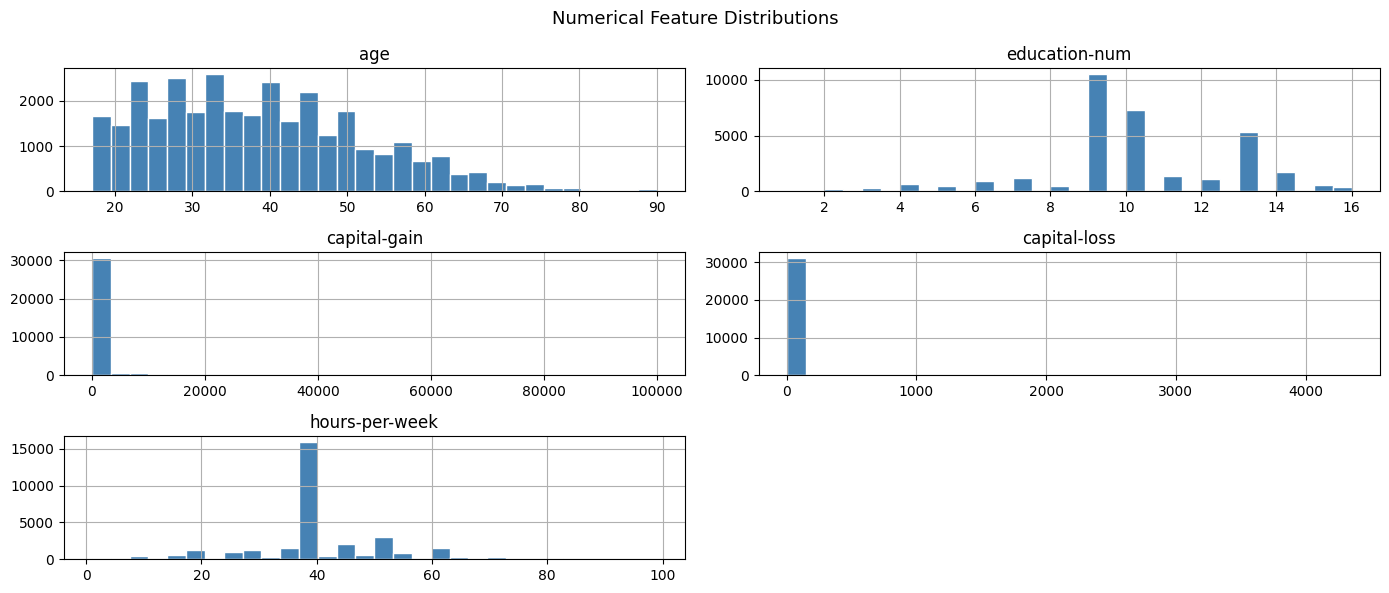

In [4]:
# Numerical feature distributions
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df[num_cols].hist(figsize=(14, 6), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'numerical_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

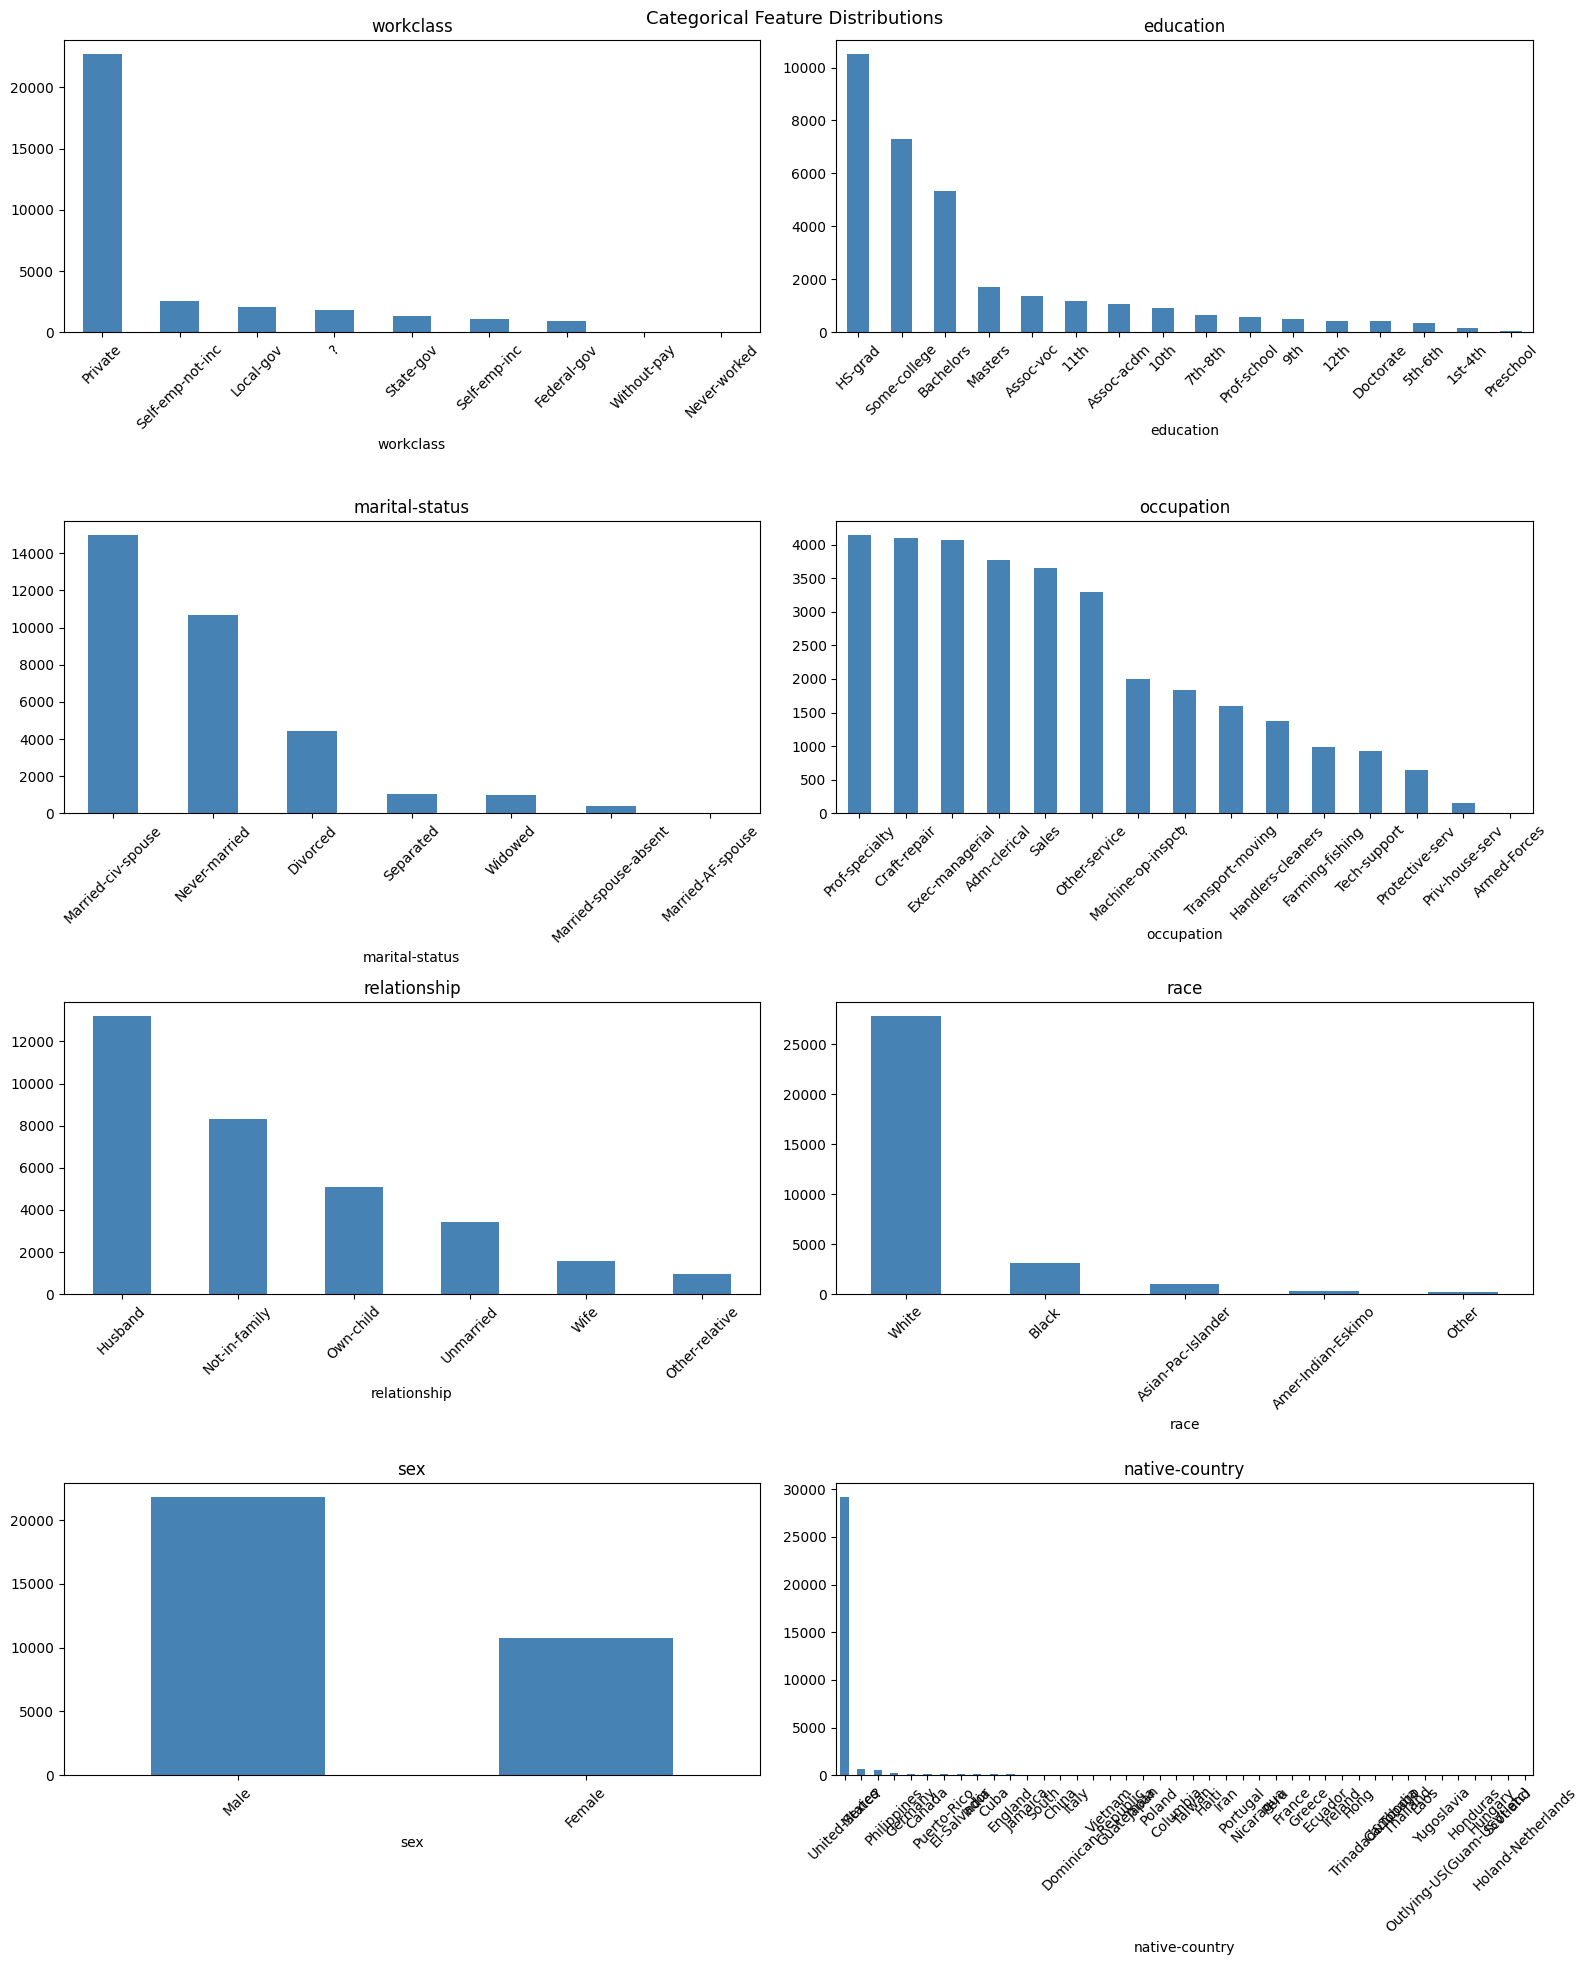

In [5]:
# Categorical feature distributions
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'categorical_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

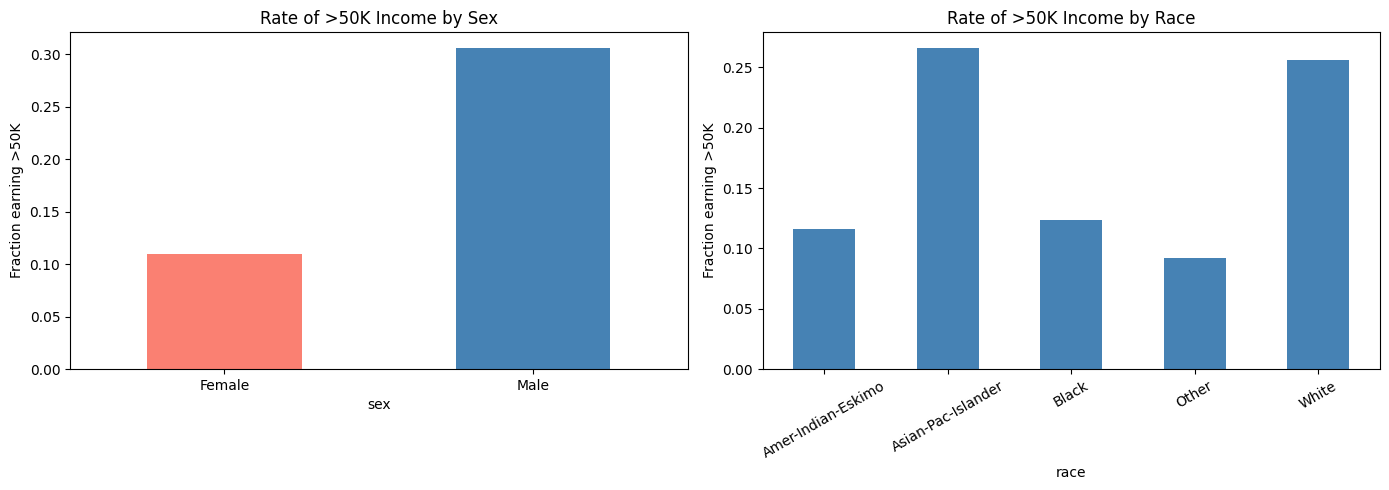

In [6]:
# Fairness preview — income rate by sex and race
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_by_sex = df.groupby('sex')['income'].apply(lambda x: (x == '>50K').mean())
income_by_sex.plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Rate of >50K Income by Sex')
axes[0].set_ylabel('Fraction earning >50K')
axes[0].tick_params(axis='x', rotation=0)

income_by_race = df.groupby('race')['income'].apply(lambda x: (x == '>50K').mean())
income_by_race.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Rate of >50K Income by Race')
axes[1].set_ylabel('Fraction earning >50K')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fairness_preview_sex_race.png'), dpi=150, bbox_inches='tight')
plt.show()

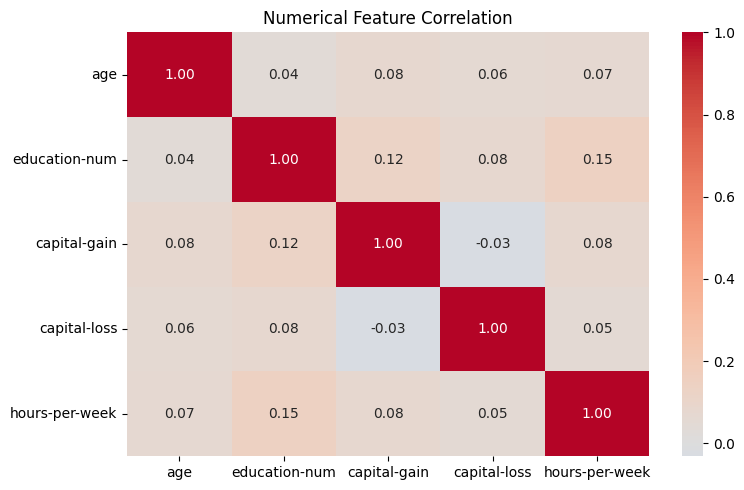

In [7]:
# Correlation heatmap (numerical columns only)
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numerical Feature Correlation')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

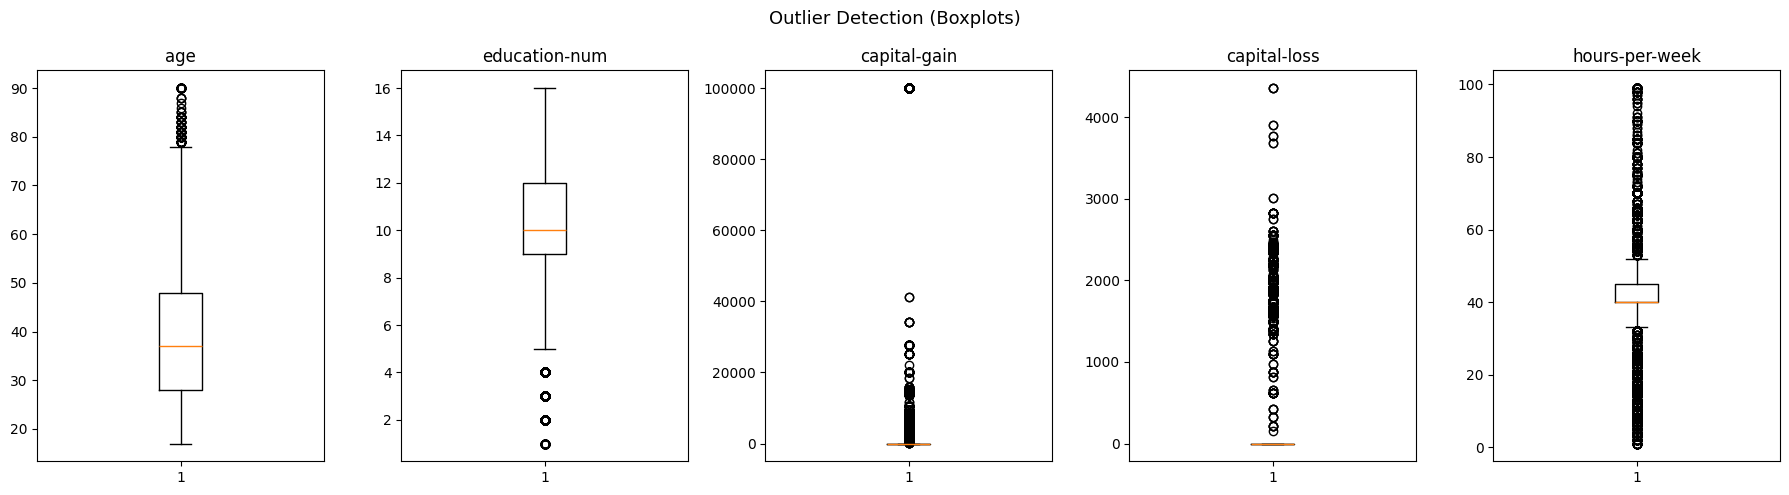

In [8]:
# Outlier detection on numerical columns
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Outlier Detection (Boxplots)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'outlier_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

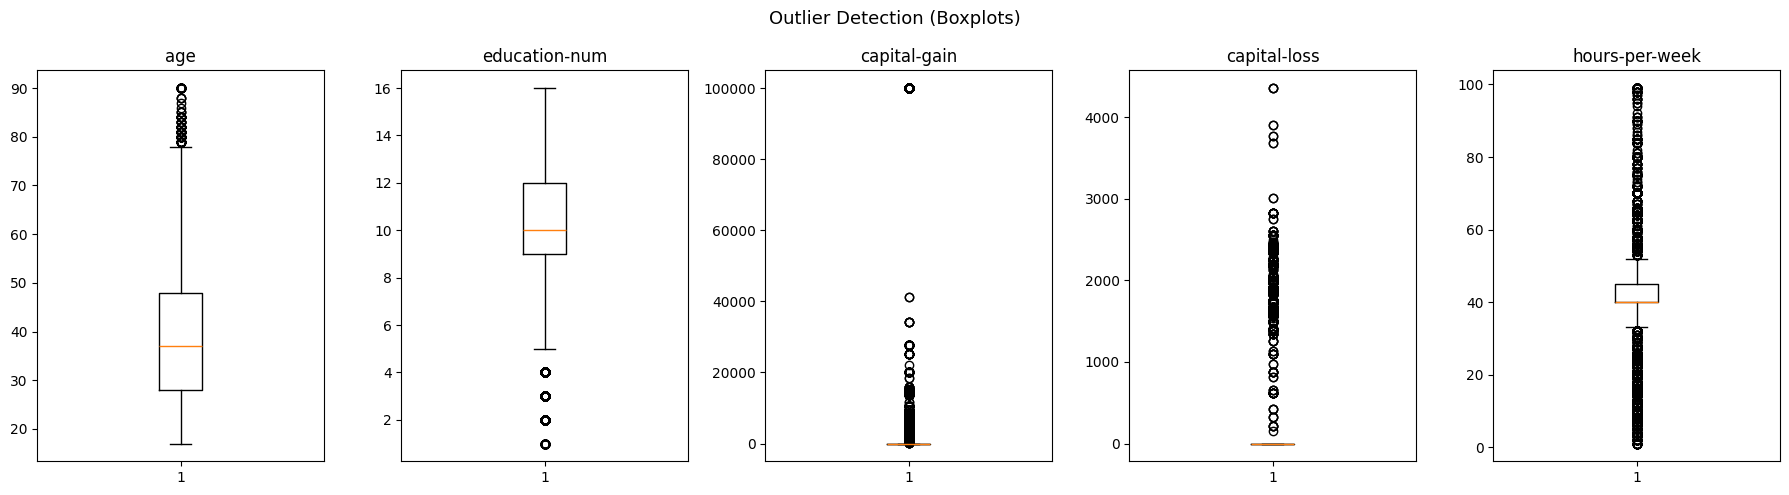

In [9]:
# Outlier detection on numerical columns
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Outlier Detection (Boxplots)', fontsize=13)
plt.tight_layout()
plt.show()

## TODO (Salman) — Answer before writing the preprocessor
1. Which columns have `?` values? How many rows are affected? Will you drop or fill?
2. How will you handle the class imbalance (~76% <=50K)?
3. Will you use LabelEncoder or OneHotEncoder for categorical columns? What are the tradeoffs?
4. Look at the fairness preview above — which groups show the biggest income gap? (Rabiya will analyze this in Phase 2)